In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "dllm").exists():
    repo_root = repo_root.parent
if (repo_root / "dllm").exists():
    sys.path.insert(0, str(repo_root))

import numpy as np
import torch
import matplotlib.pyplot as plt

from tool import TunedLens

from dllm import DLLMExpr
from dllm.DLLMBaseline import BaselineConfig

In [3]:
MODEL_PATH="/home/xiangzhong_ayl/dllm/models/LLaDA-8B-Instruct"
token_info = {
    'mask_id': 126336,
    'bos_id': 126080,
    'pad_id': 126081,
    'eos_id': 126081,
    'eot_id': 126348
}
config = BaselineConfig(
    **token_info,
    remasking="low_confidence",
    positional_weights_type='none',
    decoding_method="topk",
    factor=1,
    k=1,
    confidence_threshold=0.9,
)
sampler = DLLMExpr.from_path(model_path=MODEL_PATH, config=config)
tokenizer = sampler.tokenizer
model = sampler.model

tuned_lens = TunedLens.from_model_and_pretrained_lens(
    model=sampler.model,
    lens_path=f'{repo_root}/tool/tuned_lens/checkpoints/model.safetensors'
)
tuned_lens.eval()


Loading model and tokenizer from path: /home/xiangzhong_ayl/dllm/models/LLaDA-8B-Instruct, dllm_type: llada


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 6/6 [00:00<00:00,  6.53it/s]


cfg_scale: 0.0
temperature: 0.0
mask_id: 126336
bos_id: 126080
pad_id: 126081
eos_id: 126081
eot_id: 126348
max_gen_length: 2048
max_steps: 2048
positional_weights_type: none
max_weight: 1.0
initial_min_weight: 0.05
ur_factor: 1.0
dllm_type: llada
remasking: low_confidence
decoding_method: topk
k: 1
factor: 1
confidence_threshold: 0.9


TunedLens(
  (base_model): LLaDAModelLM(
    (model): LLaDAModel(
      (transformer): ModuleDict(
        (wte): Embedding(126464, 4096)
        (emb_drop): Dropout(p=0.0, inplace=False)
        (ln_f): RMSLayerNorm()
        (blocks): ModuleList(
          (0-31): 32 x LLaDALlamaBlock(
            (dropout): Dropout(p=0.0, inplace=False)
            (act): SiLU()
            (attn_out): Linear(in_features=4096, out_features=4096, bias=False)
            (ff_out): Linear(in_features=12288, out_features=4096, bias=False)
            (rotary_emb): RotaryEmbedding()
            (attn_norm): RMSLayerNorm()
            (ff_norm): RMSLayerNorm()
            (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (ff_proj): Linear(in_features=4096, out_features=12288, bias=False)
            (up_proj): Linear(in_feat

save imgs

In [4]:
from datasets import load_dataset
device = 'cuda:3'
sampler.model.to(device)
gen_length = 32

gsm8k_dataset = load_dataset('openai/gsm8k', 'main')
prompts = gsm8k_dataset['test']['question'][0:1]

for i, prompt_text in enumerate(prompts):
    print('=' * 20 + f" Generating prompt_idx: {i} " + "=" * 20)

    m = [{"role": "user", "content": prompt_text}]
    prompt_text = tokenizer.apply_chat_template(m, add_generation_prompt=True, tokenize=False)
    input_ids = tokenizer(prompt_text, return_tensors="pt").input_ids.to(device)

    OUT = sampler.generate(prompt=input_ids, gen_length=gen_length, max_steps=gen_length, block_length=gen_length, records=['metrics', 'state_trace'])
    out = OUT.out
    ans = tokenizer.batch_decode(out[:, input_ids.shape[1]:], skip_special_tokens=True)[0]
    
    print(f"hidden_states shape: {OUT.state_trace['hidden_states_all'].shape}\n")

    # 将hidden states保存到本地文件
    np.save(f'{repo_root}/visualization/huashan2/rawdata/hidden_states_gsm8k_pmt{i}_L{gen_length}.npy', OUT.state_trace['hidden_states_all'])

==================== Generating prompt_idx: 0 ====================
decoding method: topk, k=1, factor=1, confidence_threshold=0.9.
adjusted gen_length: 32, n_blocks: 1.
hidden_states shape: (32, 33, 108, 4096)



lens

/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20811 (\N{CJK UNIFIED IDEOGRAPH-514B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 38647 (\N{CJK UNIFIED IDEOGRAPH-96F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20174 (\N{CJK UNIFIED IDEOGRAPH-4ECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20005 (\N{CJK UNIFIED IDEOGRAPH-4E25}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 27835 (\N{CJK UNIFIED IDEOGRAPH-6CBB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 30690 (\N{CJK UNIFIED IDEOGRAPH-77E2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20225 (\N{CJK UNIFIED IDEOGRAP

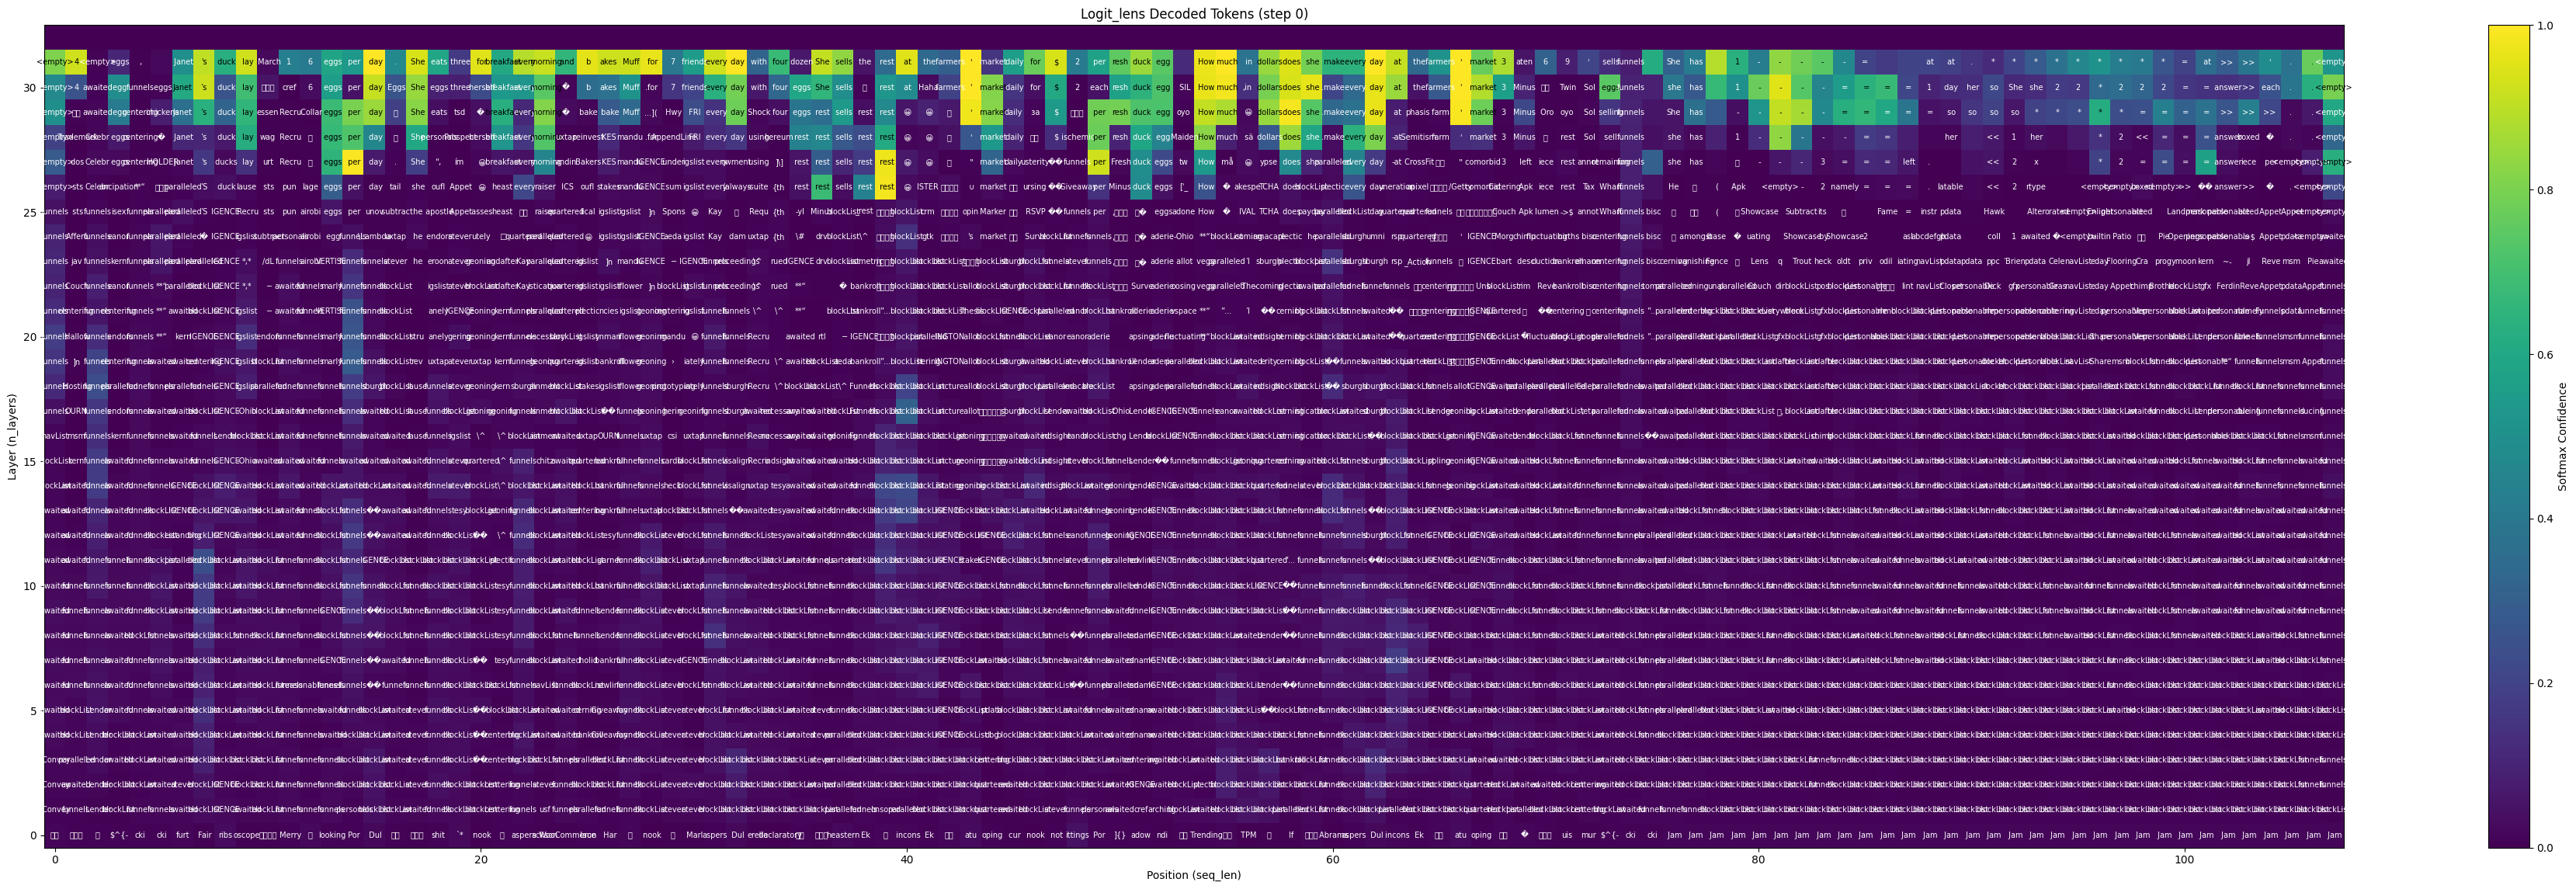

/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20937 (\N{CJK UNIFIED IDEOGRAPH-51C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 22260 (\N{CJK UNIFIED IDEOGRAPH-56F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 65311 (\N{FULLWIDTH QUESTION M

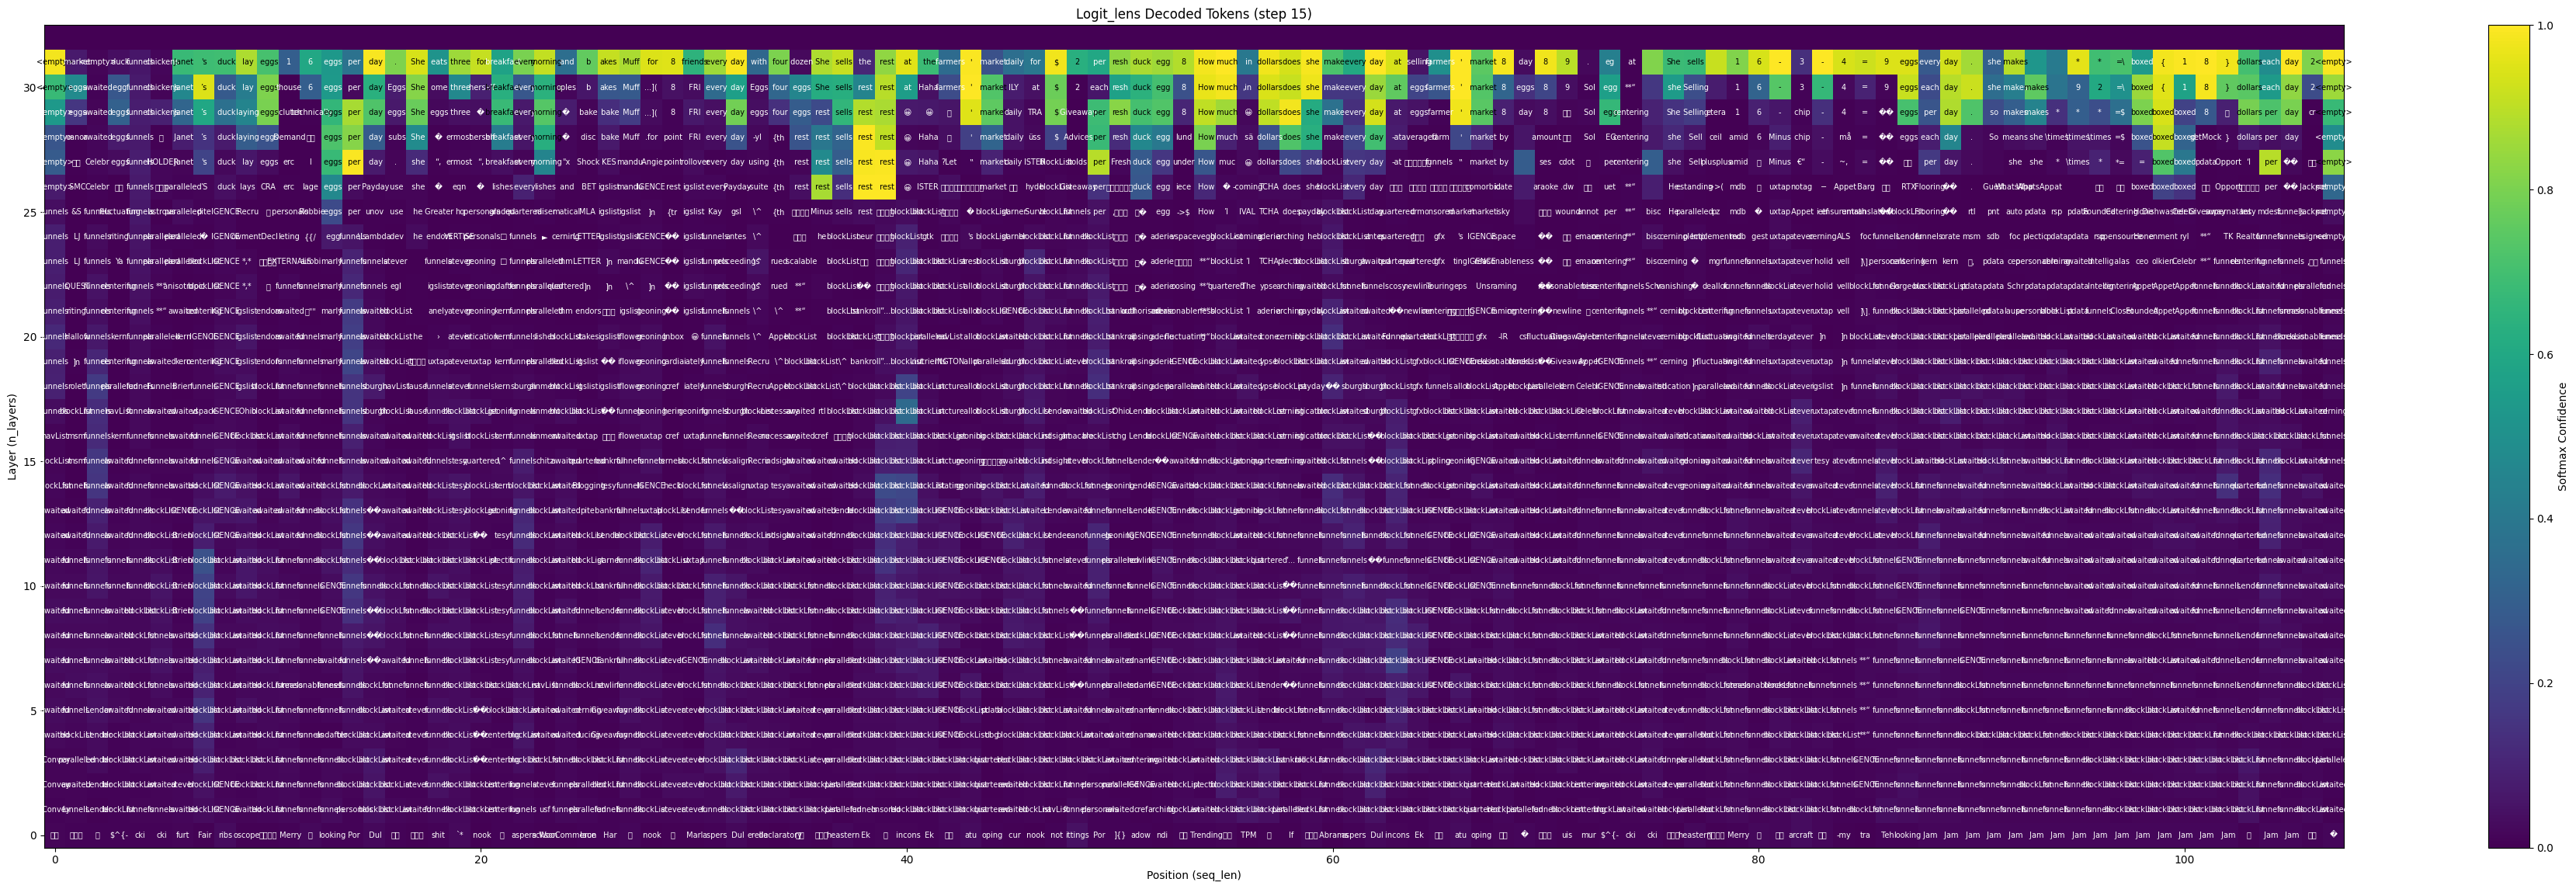

/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 35265 (\N{CJK UNIFIED IDEOGRAPH-89C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20020 (\N{CJK UNIFIED IDEOGRAPH-4E34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 35905 (\N{CJK UNIFIED IDEOGRAPH-8C41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20813 (\N{CJK UNIFIED IDEOGRAPH-514D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 20570 (\N{CJK UNIFIED IDEOGRAPH-505A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_88364/1535351092.py:50: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAP

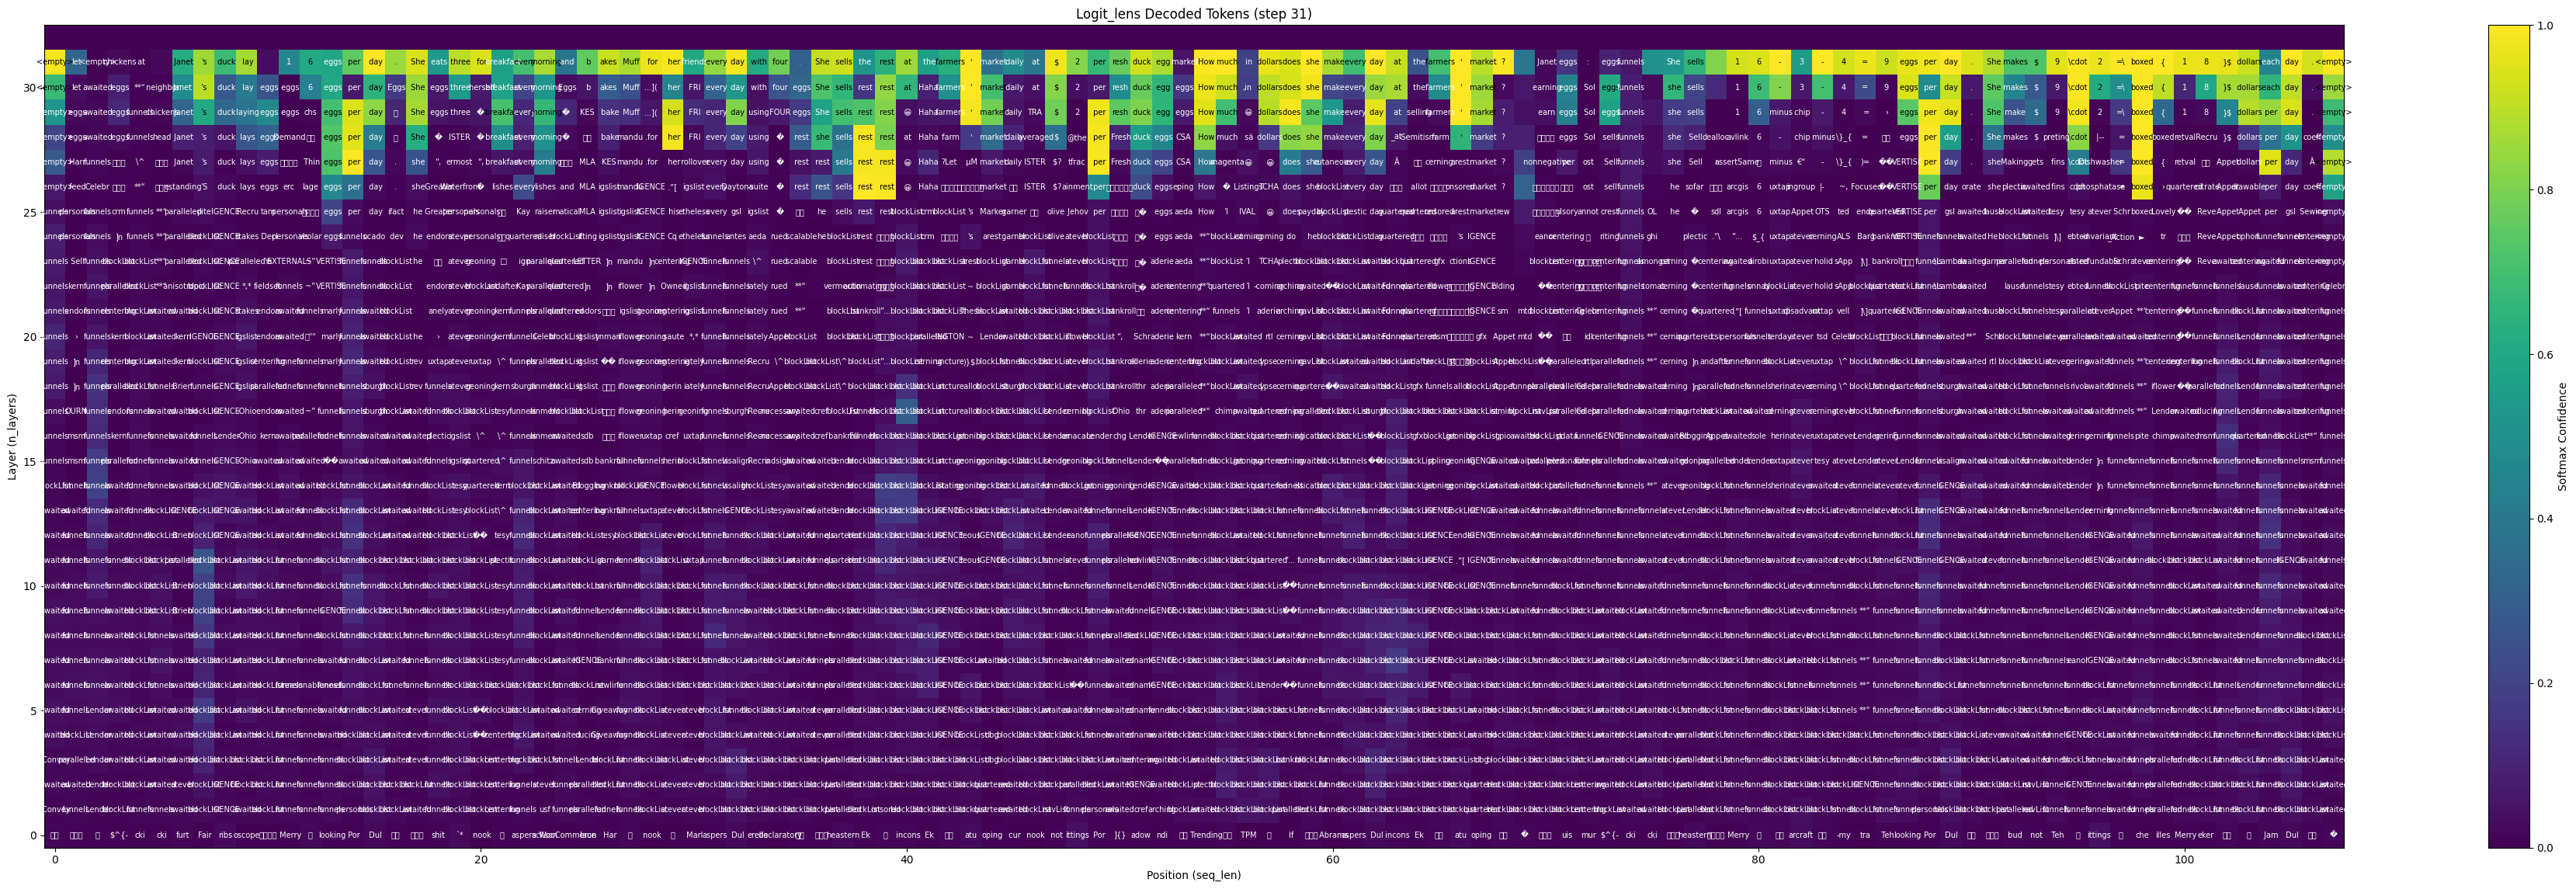

In [ ]:
step_idxs = [0,15,31]
lens_type = 'logit_lens'
hidden_states_all = np.load(f'{repo_root}/visualization/huashan2/rawdata/hidden_states_gsm8k_pmt0_L32.npy')
for step_idx in step_idxs:
    # np读取rawdata/hidden_states_gsm8k_pmt0.npy文件
    hidden_states_step_ts = torch.tensor(hidden_states_all[step_idx])  # shape: (n_layers, seq_len, hidden_size)

    n_layers, seq_len, _ = hidden_states_step_ts.shape
    token_grid = [["" for _ in range(seq_len)] for _ in range(n_layers)]
    conf_grid = np.zeros((n_layers, seq_len), dtype=np.float32)

    with torch.no_grad():
        for layer_idx in range(n_layers - 1):
            try:
                # 注意：Tuned Lens forward 需要 [Batch, Seq, Dim]
                h = hidden_states_step_ts[layer_idx].unsqueeze(0).to(dtype=sampler.model.dtype)
                if lens_type == 'tuned_lens':
                    mid_logits = tuned_lens.forward(h, layer_idx)  # [1, Seq, Vocab]
                elif lens_type == 'logit_lens':
                    mid_logits = tuned_lens.unembed(h)  # logit lens

                probs = torch.softmax(mid_logits, dim=-1)
                max_probs, max_ids = torch.max(probs, dim=-1)  # [1, Seq]

                for pos in range(seq_len):
                    token_text = tokenizer.decode([int(max_ids[0, pos])], skip_special_tokens=True)
                    if token_text == "":
                        token_text = "<empty>"
                    token_grid[layer_idx][pos] = token_text
                    conf_grid[layer_idx, pos] = float(max_probs[0, pos])
            except IndexError:
                continue

    fig_w = max(8.0, seq_len * 0.35)
    fig_h = max(6.0, n_layers * 0.35)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(conf_grid, origin='lower', aspect='auto', cmap='viridis', vmin=0.0, vmax=1.0)

    for layer_idx in range(n_layers):
        for pos in range(seq_len):
            text_color = 'white' if conf_grid[layer_idx, pos] < 0.6 else 'black'
            ax.text(pos, layer_idx, token_grid[layer_idx][pos], ha='center', va='center', color=text_color, fontsize=5)

    ax.set_xlabel('Position (seq_len)')
    ax.set_ylabel('Layer (n_layers)')
    ax.set_title(f'{lens_type.capitalize()} Decoded Tokens (step {step_idx})')
    fig.colorbar(im, ax=ax, label='Softmax Confidence')

    output_path = f'{repo_root}/visualization/huashan2/imgs/{lens_type}_tokens_step{step_idx}_L32.png'
    plt.tight_layout()
    plt.savefig(output_path, dpi=250)
    plt.show()